In [14]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fmin

**Упражнение 1**

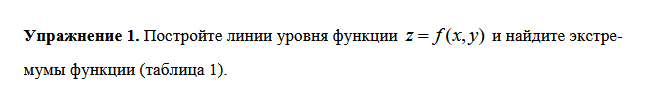

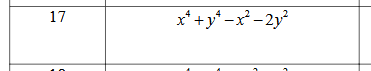

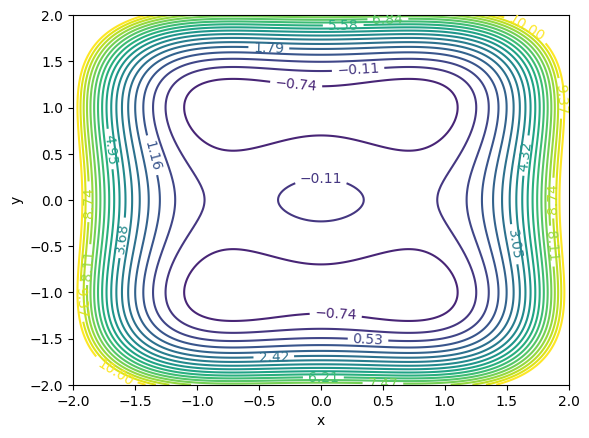

Min: 0.71  1.00  Function value at minimum: -1.25
Min: -0.71  1.00  Function value at minimum: -1.25
Min: -0.71  -1.00  Function value at minimum: -1.25
Min: 0.71  -1.00  Function value at minimum: -1.25


In [22]:
x = np.linspace(-2, 2, 201)
y = np.linspace(-2, 2, 201)
X, Y = np.meshgrid(x, y)
Z = X**4 + Y**4 - X**2 - 2*Y**2
fig, ax = plt.subplots()
cs = ax.contour(X, Y, Z, levels=np.linspace(-2, 10, 20))
ax.clabel(cs, cs.levels, inline=True, fontsize=10)
plt.xlabel('x'); plt.ylabel('y')
plt.show()

def f(t):
    x, y = t
    return x**4 + y**4 - x**2 - 2*y**2

minimum1, f_min1, _, _, _ = fmin(f, np.array([1, 1]), xtol=1e-9, disp=False, full_output=True)
minimum2, f_min2, _, _, _ = fmin(f, np.array([-1, 1]), xtol=1e-9, disp=False, full_output=True)
minimum3, f_min3, _, _, _ = fmin(f, np.array([-1, -1]), xtol=1e-9, disp=False, full_output=True)
minimum4, f_min4, _, _, _ = fmin(f, np.array([1, -1]), xtol=1e-9, disp=False, full_output=True)
print('Min:', *[f"{i:.2f} " for i in minimum1], 'Function value at minimum:', f_min1)
print('Min:', *[f"{i:.2f} " for i in minimum2], 'Function value at minimum:', f_min2)
print('Min:', *[f"{i:.2f} " for i in minimum3], 'Function value at minimum:', f_min3)
print('Min:', *[f"{i:.2f} " for i in minimum4], 'Function value at minimum:', f_min4)

**Упражнение 2**

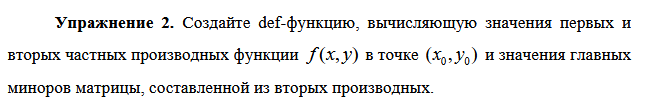

In [34]:
def deriv_and_Koshi(f, x, y, x0, y0):
    substitutions = {x: x0, y: y0}
    derivs = []
    df_dx = sp.diff(f, x)
    df_dy = sp.diff(f, y)
    derivs.append((df_dx.subs(substitutions), df_dy.subs(substitutions)))
    df_dx2 = sp.diff(df_dx, x)
    df_dy2 = sp.diff(df_dy, y)
    df_dxdy = sp.diff(df_dx, y)
    derivs.append((df_dx2.subs(substitutions), df_dy2.subs(substitutions), df_dxdy.subs(substitutions)))
    minor_1 = derivs[1][0]
    matr2 = sp.Matrix([[derivs[1][0], derivs[1][2]], [derivs[1][2], derivs[1][1]]])
    minor_2 = matr2.det()
    return derivs, minor_1, minor_2

x_sym, y_sym = sp.symbols('x y')
Z = x_sym**4 + y_sym**4 - x_sym**2 - 2*y_sym**2
derivs1, minor_1_1, minor_2_1 = deriv_and_Koshi(Z, x_sym, y_sym, minimum1[0], minimum1[1])
print("At point", *[f"{i:.2f} " for i in minimum1], f"df/dx = {derivs1[0][0]}, df/dy = {derivs1[0][1]}, minor_1 = {minor_1_1}, minor_2 = {minor_2_1}")

At point 0.71  1.00  df/dx = -1.93504052781179E-8, df/dy = 2.83741741213817E-8, minor_1 = 3.99999991790318, minor_2 = 31.9999996837155


**Упражнение 3**

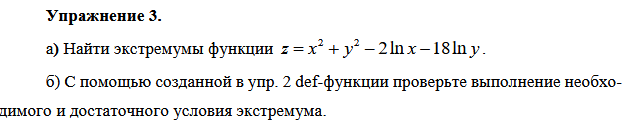

$$\frac{\partial z}{\partial x} = 2x - \frac{2}{x} = 0 \implies 2x^2 = 2 \implies x^2 = 1$$

Учитывая $x > 0$, получаем **$x = 1$**

$$\frac{\partial z}{\partial y} = 2y - \frac{18}{y} = 0 \implies 2y^2 = 18 \implies y^2 = 9$$

Учитывая $y > 0$, получаем **$y = 3$**

**Стационарная точка:** $M(1; 3)$

$$\frac{\partial^2 z}{\partial x^2} = 2 + \frac{2}{x^2} = 2 + \frac{2}{1^2} = 4$$

$$\frac{\partial^2 z}{\partial x \partial y} = 0$$

$$\frac{\partial^2 z}{\partial y^2} = 2 + \frac{18}{y^2} = 2 + \frac{18}{3^2} = 2 + 2 = 4$$

$$d^2z = 4(dx)^2 + 4(dy)^2 > 0 => M - т.min$$

In [41]:
M = (1, 3)
Z = x_sym**2 + y_sym**2 - 2*sp.log(x_sym) - 18*sp.log(y_sym)
derivs_M, minor_1_M, minor_2_M = deriv_and_Koshi(Z, x_sym, y_sym, M[0], M[1])
print("At point", *[f"{i:.2f} " for i in M], f"df/dx = {derivs_M[0][0]}, df/dy = {derivs_M[0][1]}, minor_1 = {minor_1_M}, minor_2 = {minor_2_M}")

At point 1.00  3.00  df/dx = 0, df/dy = 0, minor_1 = 4, minor_2 = 16


**Упражнение 4, 5**

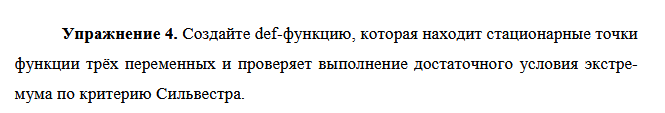

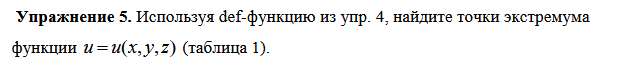

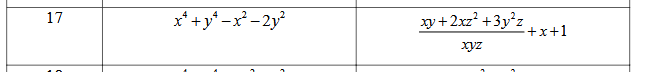

In [49]:
def extrem(f, x, y, z):
    df_dx = sp.diff(f, x)
    df_dy = sp.diff(f, y)
    df_dz = sp.diff(f, z)

    solutions = sp.solve([df_dx, df_dy, df_dz], [x, y, z], dict=True)
    real_solutions = []
    for sol in solutions:
        if all(sp.im(sol[var]) == 0 for var in (x, y, z)):
            real_solutions.append(sol)

    ans = {}
    for sol in real_solutions:
        substitutions = {x: sp.N(sol[x]), y: sp.N(sol[y]), z: sp.N(sol[z])}
        df_dx2 = sp.diff(df_dx, x).subs(substitutions)
        df_dy2 = sp.diff(df_dy, y).subs(substitutions)
        df_dz2 = sp.diff(df_dz, z).subs(substitutions)
        df_dxdy = sp.diff(df_dx, y).subs(substitutions)
        df_dxdz = sp.diff(df_dx, z).subs(substitutions)
        df_dydz = sp.diff(df_dy, z).subs(substitutions)
        minor_1 = df_dx2
        hess = sp.Matrix([[df_dx2, df_dxdy, df_dxdz],
                          [df_dxdy, df_dy2, df_dydz],
                          [df_dxdz, df_dydz, df_dz2]])
        minor_2 = hess.det()
        point = (float(substitutions[x]), float(substitutions[y]), float(substitutions[z]))
        if minor_1 > 0 and minor_2 > 0:
            ans[point] = 'local minimum'
        elif minor_1 < 0 and minor_2 > 0:
            ans[point] = 'local maximum'
        else:
            ans[point] = 'saddle point'

    return ans


x, y, z = sp.symbols('x y z')
f = (x*y + 2*x*z**2 + 3*y**2*z)/(x*y*z) + x + 1
extremum_points = extrem(f, x, y, z)
for point, extremum_type in extremum_points.items():
    print(f"At point {point}, there is a {extremum_type}.")

At point (-1.5650845800732873, 0.816496580927726, -0.6389431042462724), there is a saddle point.
At point (1.5650845800732873, 0.816496580927726, 0.6389431042462724), there is a local minimum.
